========== Simulation Summary ==========
Be bar radius          = 0.630 cm
Scatter grid step      = 0.300 cm
Number of scatter pts  = 364
Number of phi bins     = 36
Number of pixels       = 1024


>>>>>>>> Test energy: 15 keV | PSF sigma: 0.180 | lambda: 2.152 cm <<<<<<<<


>>>>>>>> Test energy: 20 keV | PSF sigma: 0.180 | lambda: 2.849 cm <<<<<<<<


>>>>>>>> Test energy: 30 keV | PSF sigma: 0.180 | lambda: 3.347 cm <<<<<<<<


>>>>>>>> Test energy: 40 keV | PSF sigma: 0.180 | lambda: 3.524 cm <<<<<<<<


>>>>>>>> Test energy: 50 keV | PSF sigma: 0.180 | lambda: 3.640 cm <<<<<<<<


>>>>>>>> Test energy: 60 keV | PSF sigma: 0.180 | lambda: 3.743 cm <<<<<<<<


>>>>>>>> Test energy: 80 keV | PSF sigma: 0.180 | lambda: 3.940 cm <<<<<<<<


>>>>>>>> Test energy: 100 keV | PSF sigma: 0.180 | lambda: 4.126 cm <<<<<<<<
Normalization check    = 1.000000

Top 12 pixels:
pixel 609 : 0.002646
pixel 97 : 0.002646
pixel 641 : 0.002646
pixel 129 : 0.002646
pixel 385 : 0.002646
pixel 865 : 0.002646
pixe

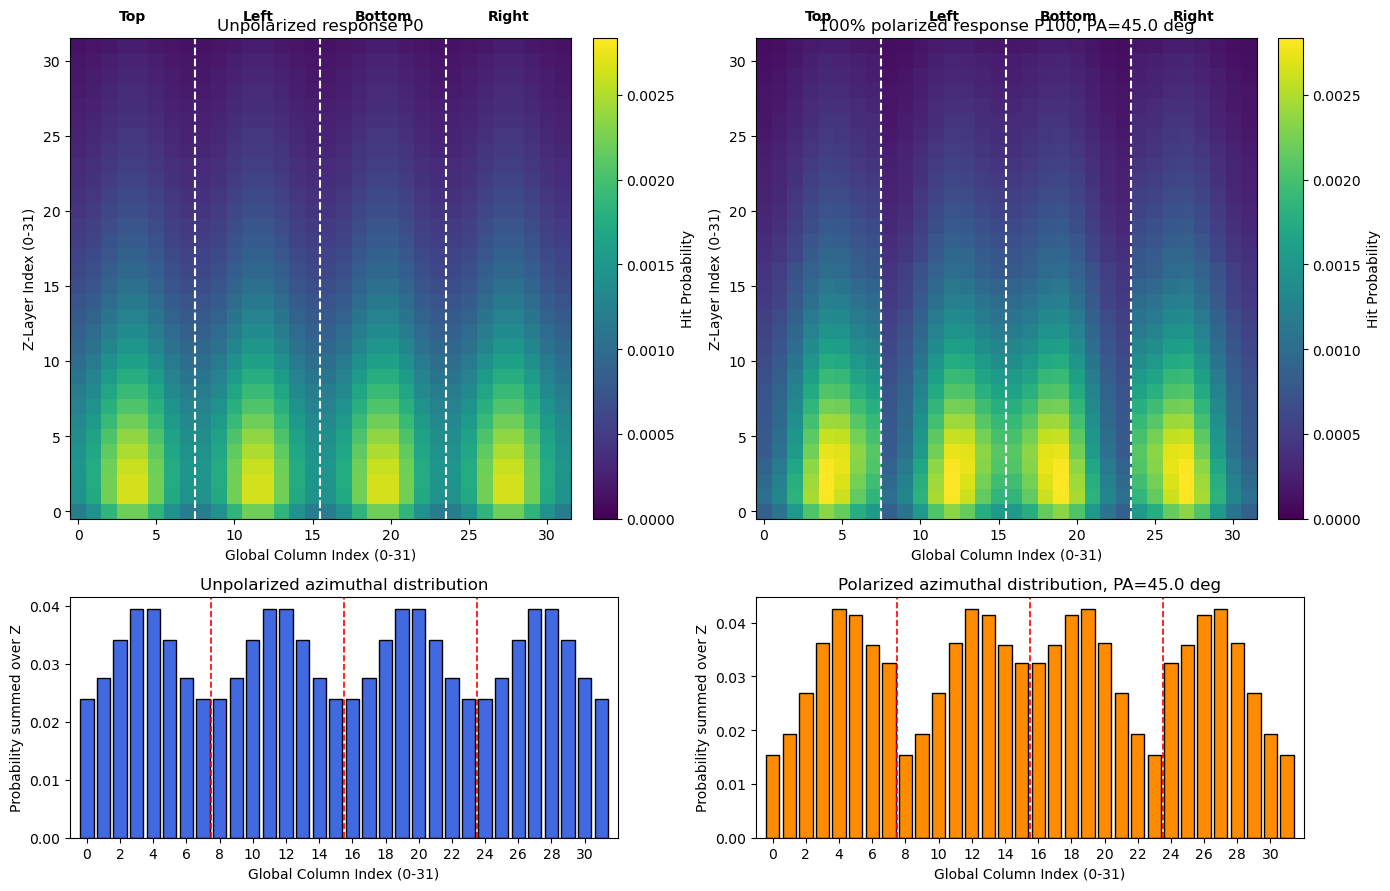


========== Sanity Check ==========
PA requested      = 45.00 deg
PA table used     = 45.00 deg
P0 pixel sum      = 1.000000
P100 pixel sum    = 1.000000
P100 phi sum      = 1.000000
P100 max phi bin  = 4 (40.0 deg)
P100 min phi bin  = 31 (310.0 deg)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path


# 1. Geometry definition

R = 0.63                      # Be bar radius (cm)
bar_center = (0.0, 0.0)
L_half = 4.0 # The half length of the beryllium rod

square_min = -1.0
square_max =  1.0

n_pixels_per_side = 8
n_total_pixels = 4 * n_pixels_per_side
side_length = square_max - square_min
pixel_size = side_length / n_pixels_per_side
n_layers_z = 32

# PSF width: detector resolution, kept constant across photon energy
sigma_psf = 0.18

# ( phi + theta) angular sampling  
n_phi = 36
phi_values = np.linspace(0, 2*np.pi, n_phi, endpoint=False)

n_theta = 18
cos_theta = np.linspace(-1, 1, n_theta)
theta_values = np.arccos(cos_theta)

# scatter grid spacing
grid_step = 0.3

# Energy-dependent Be attenuation data
be_density = 1.85 # g/cm^3

# energy：mass attenuation coefficien
attenuation_data = {
    15: 0.2512,  # cm^2/g, 1.500E-02 MeV
    20: 0.1897,
    30: 0.1615,
    40: 0.1534,
    50: 0.1485,
    60: 0.1444,
    80: 0.1372,
    100: 0.1310,
}

scattering_fraction_data = {
    15: {"coherent": 5.580e-2, "incoherent": 1.411e-1, "total_with_coherent": 3.070e-1},
    20: {"coherent": 3.538e-2, "incoherent": 1.477e-1, "total_with_coherent": 2.251e-1},
    30: {"coherent": 1.770e-2, "incoherent": 1.508e-1, "total_with_coherent": 1.792e-1},
    40: {"coherent": 1.054e-2, "incoherent": 1.493e-1, "total_with_coherent": 1.640e-1},
    50: {"coherent": 6.956e-3, "incoherent": 1.465e-1, "total_with_coherent": 1.554e-1},
    60: {"coherent": 4.920e-3, "incoherent": 1.433e-1, "total_with_coherent": 1.493e-1},
    80: {"coherent": 2.823e-3, "incoherent": 1.369e-1, "total_with_coherent": 1.401e-1},
    100: {"coherent": 1.824e-3, "incoherent": 1.308e-1, "total_with_coherent": 1.328e-1},
}

def get_mu_at_energy(energy_keV):
    energies = np.array(sorted(attenuation_data.keys()), dtype=float)
    coeffs = np.array([attenuation_data[E] for E in energies], dtype=float) # mass attenuation coefficien
    mass_coeff = np.interp(energy_keV, energies, coeffs) # if can not find the exact energy, interpolate between the two nearest energies
    return mass_coeff * be_density # get mu(E)    cm^2/g * g/cm^3 = 1/cm

def get_lambda_at_energy(energy_keV):
    return 1.0 / get_mu_at_energy(energy_keV) # lambda = 1/mu

def get_scattering_fraction_at_energy(energy_keV):

    energies = np.array(sorted(scattering_fraction_data.keys()), dtype=float)

    coherent = np.array([scattering_fraction_data[E]["coherent"] for E in energies], dtype=float)

    incoherent = np.array([scattering_fraction_data[E]["incoherent"] for E in energies], dtype=float)

    total = np.array([scattering_fraction_data[E]["total_with_coherent"] for E in energies], dtype=float)

    coherent_E = np.interp(energy_keV, energies, coherent)

    incoherent_E = np.interp(energy_keV, energies, incoherent)

    total_E = np.interp(energy_keV, energies, total)

    return (coherent_E + incoherent_E) / total_E



def outgoing_path_inside_be(x0, y0, z0, phi, theta, R, L_half, eps=1e-12):
    dx = np.sin(theta) * np.cos(phi)
    dy = np.sin(theta) * np.sin(phi)
    dz = np.cos(theta)

    t_candidates = []

    # Exit through the cylindrical side wall: x^2 + y^2 = R^2
    a = dx*dx + dy*dy
    b = 2.0 * (x0*dx + y0*dy)
    c = x0*x0 + y0*y0 - R*R
    if a > eps:
        disc = b*b - 4.0*a*c
        if disc >= 0:
            sqrt_disc = np.sqrt(max(disc, 0.0))
            for t in [(-b - sqrt_disc) / (2.0*a), (-b + sqrt_disc) / (2.0*a)]:
                if t > eps:
                    z_exit = z0 + t * dz
                    if -L_half - eps <= z_exit <= L_half + eps:
                        t_candidates.append(t)

    # Exit through the end caps: z = +/- L_half
    if abs(dz) > eps:
        for z_cap in [-L_half, L_half]:
            t = (z_cap - z0) / dz
            if t > eps:
                x_exit = x0 + t * dx
                y_exit = y0 + t * dy
                if x_exit*x_exit + y_exit*y_exit <= R*R + eps:
                    t_candidates.append(t)

    if len(t_candidates) == 0:
        return 0.0

    return min(t_candidates)


def scatter_weight_at_energy(x0, y0, z0, phi, theta, energy_keV):
    # incoming photons travel along +z from z = -L_half.
    mu = get_mu_at_energy(energy_keV)
    incoming_depth = z0 + L_half
    outgoing_path = outgoing_path_inside_be(x0, y0, z0, phi, theta, R, L_half)
    scattering_fraction = get_scattering_fraction_at_energy(energy_keV)

    return mu * np.exp(-mu * incoming_depth) * np.exp(-mu * outgoing_path) * scattering_fraction


# 2. Build detector pixels on a square boundary
#    Pixel ordering:
#      0-255: top
#      256-511: left
#      512-767: bottom
#      768-1023: right


def build_pixels(square_min, square_max, L_half, n_pixels_per_side, n_layers_z):
    pixels = []
    pixel_size_xy = (square_max - square_min) / n_pixels_per_side # 2cm/ 8 pixles
    pixel_size_z = (2.0 * L_half) / n_layers_z # 8cm /32 pixles

    z_centers = [(-L_half + (j + 0.5) * pixel_size_z) for j in range(n_layers_z)]

    #  Top side: y = square_max 
    for i in range(n_pixels_per_side):
        x_center = square_min + (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z): 
            pixels.append({
                "pixel_id": len(pixels),
                "side": "top",
                "column_idx": i,
                "layer_idx": j,
                "x_center": x_center,
                "y_center": square_max,
                "z_center": z_centers[j]
            })

    #  Left wall: x = square_min 
    for i in range(n_pixels_per_side):
        y_center = square_max - (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z):
            pixels.append({
                "pixel_id": len(pixels),
                "side": "left",
                "column_idx": i,
                "layer_idx": j,
                "x_center": square_min,
                "y_center": y_center,
                "z_center": z_centers[j]
            })

    #  Bottom wall: y = square_min 
    for i in range(n_pixels_per_side):
        x_center = square_min + (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z):
            pixels.append({
                "pixel_id": len(pixels),
                "side": "bottom",
                "column_idx": i,
                "layer_idx": j,
                "x_center": x_center,
                "y_center": square_min,
                "z_center": z_centers[j]
            })

    # Right wall: x = square_max 
    for i in range(n_pixels_per_side):
        y_center = square_max - (i + 0.5) * pixel_size_xy
        for j in range(n_layers_z):
            pixels.append({
                "pixel_id": len(pixels),
                "side": "right",
                "column_idx": i,
                "layer_idx": j,
                "x_center": square_max,
                "y_center": y_center,
                "z_center": z_centers[j]
            })

    return pixels


pixels = build_pixels(square_min, square_max, L_half, n_pixels_per_side, n_layers_z)


# 3. Build a scatter grid inside a circular Be bar

#### update from 2D to 3D
def build_scatter_points(R, L_half, grid_step):
    scatter_points = []
    # Use a center-symmetric xy grid to avoid the small offset caused by starting at -R = -0.63.
    # For grid_step = 0.3 this gives: -0.6, -0.3, 0.0, 0.3, 0.6.
    x_vals = np.arange(-0.6, 0.6 + 1e-12, grid_step)
    y_vals = np.arange(-0.6, 0.6 + 1e-12, grid_step)
    z_vals = np.arange(-L_half, L_half + grid_step, grid_step)

    for x in x_vals:
        for y in y_vals:
            if x*x + y*y <= R*R:
                for z in z_vals:
                    scatter_points.append((x, y, z))
    return scatter_points


scatter_points = build_scatter_points(R, L_half, grid_step)



# 4. Trace a ray from (x0, y0) along direction phi
#    to the first hit point on the square boundary

def trace_ray_to_square(x0, y0, z0, phi, theta, square_min, square_max, L_half, eps=1e-12):
    dx = np.sin(theta) * np.cos(phi)
    dy = np.sin(theta) * np.sin(phi)
    dz = np.cos(theta)
    # direction of photon emission (dx, dy, dz)
    t_candidates = []

    # vertical boundaries
    if abs(dx) > eps:
        # x = square_max (right wall)
        t_right = (square_max - x0) / dx
        if t_right > 0:
            y_right = y0 + t_right * dy # y and z coordinates when the photon hits the x boundary
            z_right = z0 + t_right * dz
            if (square_min - eps <= y_right <= square_max + eps) and (abs(z_right) <= L_half + eps):
                t_candidates.append((t_right, square_max, y_right, z_right, "right"))

        # x = square_min (left wall)
        t_left = (square_min - x0) / dx
        if t_left > 0:
            y_left = y0 + t_left * dy
            z_left = z0 + t_left * dz
            if (square_min - eps <= y_left <= square_max + eps) and (abs(z_left) <= L_half + eps):
                t_candidates.append((t_left, square_min, y_left, z_left, "left"))

    # horizontal boundaries
    if abs(dy) > eps:
        # y = square_max (top wall)
        t_top = (square_max - y0) / dy
        if t_top > 0:
            x_top = x0 + t_top * dx
            z_top = z0 + t_top * dz
            if (square_min - eps <= x_top <= square_max + eps) and (abs(z_top) <= L_half + eps):
                t_candidates.append((t_top, x_top, square_max, z_top, "top"))

        # y = square_min (bottom wall)
        t_bottom = (square_min - y0) / dy
        if t_bottom > 0:
            x_bottom = x0 + t_bottom * dx
            z_bottom = z0 + t_bottom * dz
            if (square_min - eps <= x_bottom <= square_max + eps) and (abs(z_bottom) <= L_half + eps):
                t_candidates.append((t_bottom, x_bottom, square_min, z_bottom, "bottom"))

    if len(t_candidates) == 0:
        return None

    t_hit, x_hit, y_hit, z_hit, hit_side = min(t_candidates, key=lambda item: item[0])
    return x_hit, y_hit, z_hit, hit_side



# 5. Hard assignment: hit point -> pixel ID
#    (kept for checking/debugging)

def hit_to_pixel_id(x_hit, y_hit, z_hit, hit_side,
                    square_min, square_max, L_half,
                    n_pixels_per_side, n_layers_z):
    pixel_size_xy = (square_max - square_min) / n_pixels_per_side
    pixel_size_z = (2.0 * L_half) / n_layers_z
    z_min = -L_half

    z_layer_idx = int((z_hit - z_min) / pixel_size_z)   # photon strikes the # z-layer
    if z_layer_idx < 0: z_layer_idx = 0                 
    if z_layer_idx >= n_layers_z: z_layer_idx = n_layers_z - 1

    pixels_per_wall = n_pixels_per_side * n_layers_z # 8*32 = 256 pixels per side wall

    if hit_side == "top":   # ID = 0-255
        col_idx = int((x_hit - square_min) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1 # Prevent "cornering" type of boundary violation crashes
        wall_offset = 0 * pixels_per_wall

    elif hit_side == "left": # ID = 256-511
        col_idx = int((square_max - y_hit) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1
        wall_offset = 1 * pixels_per_wall

    elif hit_side == "bottom": # ID = 512-767
        col_idx = int((x_hit - square_min) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1
        wall_offset = 2 * pixels_per_wall

    elif hit_side == "right": # ID = 768-1023
        col_idx = int((square_max - y_hit) / pixel_size_xy)
        if col_idx >= n_pixels_per_side: col_idx = n_pixels_per_side - 1
        wall_offset = 3 * pixels_per_wall

    else:
        return None

    hard_pixel = wall_offset + col_idx * n_layers_z + z_layer_idx
    
    return hard_pixel




#  PSF weighting to all pixels
#    polsim-like Gaussian idea:
#        weight ~ exp(-dist2 / (2*sigma^2))


def psf_weights_to_pixels(x_hit, y_hit, z_hit, pixels, sigma):
    weights = []

    for p in pixels:
        dx = p["x_center"] - x_hit
        dy = p["y_center"] - y_hit
        dz = p["z_center"] - z_hit
        dist2 = dx*dx + dy*dy + dz*dz
        w = np.exp(-dist2 / (2.0 * sigma * sigma))
        weights.append(w)

    weights = np.array(weights, dtype=float)

    if weights.sum() > 0:
        weights /= weights.sum()

    return weights



# 7. One-ray response:
#       (x0, y0, phi) -> probability over 32 pixels

def ray_response(x0, y0, z0, phi, theta, pixels, sigma):
    result = trace_ray_to_square(x0, y0, z0, phi, theta, square_min, square_max, L_half, eps=1e-12)
    if result is None:
        return np.zeros(len(pixels), dtype=float)

    x_hit, y_hit, z_hit, hit_side = result
    return psf_weights_to_pixels(x_hit, y_hit, z_hit, pixels, sigma)



# 8. One-point response:
#       fixed (x0, y0, z0), integrate over all phi and theta

def point_response_over_angles(x0, y0, z0, phi_values, theta_values, pixels, sigma, energy_keV=None):
    total_probs = np.zeros(len(pixels), dtype=float)

    for phi in phi_values:
        for theta in theta_values:
            if energy_keV is None:
                ray_weight = 1.0
            else:
                ray_weight = scatter_weight_at_energy(x0, y0, z0, phi, theta, energy_keV)
            total_probs += ray_weight * ray_response(x0, y0, z0, phi, theta, pixels, sigma)

    if energy_keV is None and total_probs.sum() > 0:
        total_probs /= total_probs.sum()

    return total_probs



# 9. Full Be bar response:
#       integrate over all scatter points


def normalize_response(response):
    # Convert an unnormalized pixel response/count vector into a probability table.
    # This is used for per-energy tables where each energy should sum to 1.
    response = np.array(response, dtype=float)
    total = response.sum()
    if total > 0:
        return response / total
    return response


def total_response_over_bar(scatter_points, phi_values, theta_values, pixels, sigma, energy_keV=None, normalize=True):
    # If normalize=False, keep the absolute relative yield for this energy.
    # If normalize=True, return a pixel probability distribution with sum = 1.
    total_probs = np.zeros(len(pixels), dtype=float) #1024 pixels

    for (x0, y0, z0) in scatter_points:
        point_probs = point_response_over_angles(
            x0, y0, z0, phi_values, theta_values, pixels, sigma, energy_keV=energy_keV
        )
        total_probs += point_probs

    if normalize:
        total_probs = normalize_response(total_probs)

    return total_probs



# 10. Run the full simulation

energies_to_test = [15, 20, 30, 40, 50, 60, 80, 100]

# Per-energy normalized probability tables:
#   results[E][pid] = P(pixel pid | energy E), so each results[E].sum() = 1.
results = {}

# Per-energy unnormalized physical responses:
#   raw_results[E] keeps the relative yield from mu(E), Be attenuation, outgoing escape,
#   and scattering_fraction(E). These raw responses are used for the energy-integrated result.
raw_results = {}

# Optional diagnostic table showing how much each energy contributes to the final spectrum sum.
energy_contribution_table = []

spectrum_T = 1.65 # Cyg X-1; use 2.15 for Crab

# Spectrum-integrated response uses raw counts, not per-energy normalized shapes.
# Final normalization happens only after all energies have been weighted and summed.
spectrum_weighted_counts = np.zeros(len(pixels), dtype=float)

print("========== Simulation Summary ==========")
print(f"Be bar radius          = {R:.3f} cm")
print(f"Scatter grid step      = {grid_step:.3f} cm")
print(f"Number of scatter pts  = {len(scatter_points)}")
print(f"Number of phi bins     = {len(phi_values)}")
print(f"Number of pixels       = {len(pixels)}")


for E in energies_to_test:
    lambda_E = get_lambda_at_energy(E)
    print(f"\n\n>>>>>>>> Test energy: {E} keV | PSF sigma: {sigma_psf:.3f} | lambda: {lambda_E:.3f} cm <<<<<<<<")

    # Raw response keeps the total relative yield for this energy.
    # It should be used when summing over the source spectrum.
    raw_probs = total_response_over_bar(
        scatter_points=scatter_points,
        phi_values=phi_values,
        theta_values=theta_values,
        pixels=pixels,
        sigma=sigma_psf,
        energy_keV=E,
        normalize=False
    )

    # Normalized response is the per-energy pixel probability table.
    # It should be used when reporting P(pixel | energy E).
    total_probs = normalize_response(raw_probs)

    raw_results[E] = raw_probs
    results[E] = total_probs

    # Source spectrum weight: power-law source intensity at this energy.
    spectrum_weight = E ** (-spectrum_T)
    weighted_yield = spectrum_weight * raw_probs.sum()

    # Energy-integrated result uses raw physical yields, then normalizes once at the end.
    spectrum_weighted_counts += spectrum_weight * raw_probs

    energy_contribution_table.append({
        "energy_keV": E,
        "source_spectrum_weight": spectrum_weight,
        "raw_yield": raw_probs.sum(),
        "weighted_yield": weighted_yield,
    })

# Final source-spectrum-integrated pixel probability distribution.
# This is the second result: all energies combined, with final sum over pixels = 1.
total_probs = normalize_response(spectrum_weighted_counts)

weighted_yield_sum = sum(row["weighted_yield"] for row in energy_contribution_table)
for row in energy_contribution_table:
    if weighted_yield_sum > 0:
        row["fraction_of_total_weighted_yield"] = row["weighted_yield"] / weighted_yield_sum
    else:
        row["fraction_of_total_weighted_yield"] = 0.0
    
print(f"Normalization check    = {total_probs.sum():.6f}")

print("\nTop 12 pixels:")
top_ids = np.argsort(total_probs)[::-1][:12]
for pid in top_ids:
    print(f"pixel {pid:2d} : {total_probs[pid]:.6f}")

top_sum    = total_probs[0:256].sum()
left_sum   = total_probs[256:512].sum()
bottom_sum = total_probs[512:768].sum()
right_sum  = total_probs[768:1024].sum()

print("\nSide totals:")
print(f"top    = {top_sum:.6f}")
print(f"left   = {left_sum:.6f}")
print(f"bottom = {bottom_sum:.6f}")
print(f"right  = {right_sum:.6f}")

# Generate per-energy pixel probability tables.
# Each results[E] is normalized separately, so every per-energy table has sum(probability) = 1.
output_dir = Path("energy_pixel_probability_tables")
output_dir.mkdir(exist_ok=True)

combined_table_path = output_dir / "per_energy_pixel_probabilities_all.csv"
summary_table_path = output_dir / "per_energy_summary.csv"

with combined_table_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "energy_keV", "pixel_id", "side", "column_idx", "layer_idx",
        "x_center", "y_center", "z_center", "probability"
    ])
    for E in energies_to_test:
        for p in pixels:
            pid = p["pixel_id"]
            writer.writerow([
                E, pid, p["side"], p["column_idx"], p["layer_idx"],
                p["x_center"], p["y_center"], p["z_center"], results[E][pid]
            ])

with summary_table_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "energy_keV", "probability_sum", "max_pixel_id", "max_probability",
        "top_sum", "left_sum", "bottom_sum", "right_sum", "raw_yield"
    ])
    for E in energies_to_test:
        probs = results[E]
        max_pid = int(np.argmax(probs))
        writer.writerow([
            E, probs.sum(), max_pid, probs[max_pid],
            probs[0:256].sum(), probs[256:512].sum(),
            probs[512:768].sum(), probs[768:1024].sum(), raw_results[E].sum()
        ])

for E in energies_to_test:
    per_energy_table_path = output_dir / f"pixel_probabilities_{E}keV.csv"
    with per_energy_table_path.open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "pixel_id", "side", "column_idx", "layer_idx",
            "x_center", "y_center", "z_center", "probability"
        ])
        for p in pixels:
            pid = p["pixel_id"]
            writer.writerow([
                pid, p["side"], p["column_idx"], p["layer_idx"],
                p["x_center"], p["y_center"], p["z_center"], results[E][pid]
            ])

print("\nGenerated per-energy pixel probability tables:")
print(f"combined table = {combined_table_path}")
print(f"summary table  = {summary_table_path}")
print(f"per-energy tables are in: {output_dir}")


# Generate lookup tables that keep the azimuth-angle dimension.
#
# Goal:
#   Build a table like P(pixel | energy, azimuth angle).
#
# Why we need this:
#   Later, in maximum likelihood, the teacher's formula uses something like
#       P100 = table(row, col, phi - PA)
#   This means we need to keep phi as a separate lookup dimension instead of
#   summing over all phi values too early.
#
# Important:
#   This table does NOT include polarization modulation weight yet.
#   It only stores the detector response for each simulated azimuth angle.
#
# Normalization:
#   For each fixed (energy, phi_bin), the 1024 pixel probabilities sum to 1:
#       sum_pixel P(pixel | energy, phi_bin) = 1

phi_output_dir = Path("energy_phi_pixel_probability_tables")
phi_output_dir.mkdir(exist_ok=True)

energy_values = np.array(energies_to_test, dtype=float)
n_energy = len(energy_values)
n_phi_bins = len(phi_values)
n_pixels = len(pixels)

# This array stores the lookup table.
# Shape: (number of energies, number of phi bins, number of pixels)
# Example: response_by_energy_phi[0, 3, 897]
# means: energy index 0, phi bin 3, pixel 897.
response_by_energy_phi = np.zeros((n_energy, n_phi_bins, n_pixels), dtype=float)

# Pixel center coordinates. These are used to calculate the Gaussian PSF distance
# from the ray hit point to every detector pixel.
pixel_x = np.array([p["x_center"] for p in pixels], dtype=float)
pixel_y = np.array([p["y_center"] for p in pixels], dtype=float)
pixel_z = np.array([p["z_center"] for p in pixels], dtype=float)

# Pre-calculate energy-dependent constants so we do not recompute them repeatedly.
mu_values = np.zeros(n_energy, dtype=float)
scattering_fraction_values = np.zeros(n_energy, dtype=float)
for energy_idx in range(n_energy):
    energy_keV = energy_values[energy_idx]
    mu_values[energy_idx] = get_mu_at_energy(energy_keV)
    scattering_fraction_values[energy_idx] = get_scattering_fraction_at_energy(energy_keV)


def trace_ray_to_square_fast(x0, y0, z0, phi, theta, eps=1e-12):
    # Same idea as trace_ray_to_square(), but returns only the hit coordinates.
    # This keeps the lookup-table generation a little faster and easier to store.
    dx = np.sin(theta) * np.cos(phi)
    dy = np.sin(theta) * np.sin(phi)
    dz = np.cos(theta)
    t_candidates = []

    if abs(dx) > eps:
        t_right = (square_max - x0) / dx
        if t_right > 0:
            y_right = y0 + t_right * dy
            z_right = z0 + t_right * dz
            if (square_min - eps <= y_right <= square_max + eps) and (abs(z_right) <= L_half + eps):
                t_candidates.append((t_right, square_max, y_right, z_right))

        t_left = (square_min - x0) / dx
        if t_left > 0:
            y_left = y0 + t_left * dy
            z_left = z0 + t_left * dz
            if (square_min - eps <= y_left <= square_max + eps) and (abs(z_left) <= L_half + eps):
                t_candidates.append((t_left, square_min, y_left, z_left))

    if abs(dy) > eps:
        t_top = (square_max - y0) / dy
        if t_top > 0:
            x_top = x0 + t_top * dx
            z_top = z0 + t_top * dz
            if (square_min - eps <= x_top <= square_max + eps) and (abs(z_top) <= L_half + eps):
                t_candidates.append((t_top, x_top, square_max, z_top))

        t_bottom = (square_min - y0) / dy
        if t_bottom > 0:
            x_bottom = x0 + t_bottom * dx
            z_bottom = z0 + t_bottom * dz
            if (square_min - eps <= x_bottom <= square_max + eps) and (abs(z_bottom) <= L_half + eps):
                t_candidates.append((t_bottom, x_bottom, square_min, z_bottom))

    if len(t_candidates) == 0:
        return None

    closest_hit = min(t_candidates, key=lambda item: item[0])
    x_hit = closest_hit[1]
    y_hit = closest_hit[2]
    z_hit = closest_hit[3]
    return x_hit, y_hit, z_hit


for x0, y0, z0 in scatter_points:
    incoming_depth = z0 + L_half

    for phi_idx, phi in enumerate(phi_values):
        for theta in theta_values:
            hit = trace_ray_to_square_fast(x0, y0, z0, phi, theta)
            if hit is None:
                continue

            x_hit, y_hit, z_hit = hit

            # This is the distance the scattered photon travels inside Be
            # before escaping the Be rod. It depends on the outgoing direction.
            outgoing_path = outgoing_path_inside_be(x0, y0, z0, phi, theta, R, L_half)

            # Gaussian PSF response over all pixels.
            # This gives a 1024-element vector: one probability for each pixel.
            dist2 = (pixel_x - x_hit)**2 + (pixel_y - y_hit)**2 + (pixel_z - z_hit)**2
            pixel_response = np.exp(-dist2 / (2.0 * sigma_psf * sigma_psf))
            if pixel_response.sum() > 0:
                pixel_response = pixel_response / pixel_response.sum()

            # Add this ray's contribution separately for each energy.
            # This is intentionally written as a simple loop instead of NumPy broadcasting.
            for energy_idx in range(n_energy):
                mu = mu_values[energy_idx]
                scattering_fraction = scattering_fraction_values[energy_idx]

                incoming_weight = mu * np.exp(-mu * incoming_depth)
                outgoing_weight = np.exp(-mu * outgoing_path)
                ray_weight = incoming_weight * outgoing_weight * scattering_fraction

                response_by_energy_phi[energy_idx, phi_idx, :] += ray_weight * pixel_response

# Normalize each (energy, phi_bin) table over pixels.
for energy_idx in range(n_energy):
    for phi_idx in range(n_phi_bins):
        response_by_energy_phi[energy_idx, phi_idx, :] = normalize_response(
            response_by_energy_phi[energy_idx, phi_idx, :]
        )

# Write one big CSV containing all energies and all phi bins.
phi_combined_table_path = phi_output_dir / "per_energy_phi_pixel_probabilities_all.csv"
with phi_combined_table_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "energy_keV", "phi_bin", "phi_center_rad", "phi_center_deg",
        "pixel_id", "side", "column_idx", "layer_idx",
        "x_center", "y_center", "z_center", "probability"
    ])

    for energy_idx in range(n_energy):
        energy_keV = energy_values[energy_idx]
        for phi_idx in range(n_phi_bins):
            phi = phi_values[phi_idx]
            for p in pixels:
                pid = p["pixel_id"]
                writer.writerow([
                    int(energy_keV), phi_idx, phi, np.degrees(phi),
                    pid, p["side"], p["column_idx"], p["layer_idx"],
                    p["x_center"], p["y_center"], p["z_center"],
                    response_by_energy_phi[energy_idx, phi_idx, pid]
                ])

# Also write one CSV per energy, which is easier to inspect by hand.
for energy_idx in range(n_energy):
    energy_keV = energy_values[energy_idx]
    phi_energy_table_path = phi_output_dir / f"phi_pixel_probabilities_{int(energy_keV)}keV.csv"

    with phi_energy_table_path.open("w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "phi_bin", "phi_center_rad", "phi_center_deg",
            "pixel_id", "side", "column_idx", "layer_idx",
            "x_center", "y_center", "z_center", "probability"
        ])

        for phi_idx in range(n_phi_bins):
            phi = phi_values[phi_idx]
            for p in pixels:
                pid = p["pixel_id"]
                writer.writerow([
                    phi_idx, phi, np.degrees(phi),
                    pid, p["side"], p["column_idx"], p["layer_idx"],
                    p["x_center"], p["y_center"], p["z_center"],
                    response_by_energy_phi[energy_idx, phi_idx, pid]
                ])

# Write a small summary file for quick checks.
phi_summary_table_path = phi_output_dir / "per_energy_phi_summary.csv"
with phi_summary_table_path.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "energy_keV", "phi_bin", "phi_center_deg",
        "probability_sum", "max_pixel_id", "max_probability"
    ])

    for energy_idx in range(n_energy):
        energy_keV = energy_values[energy_idx]
        for phi_idx in range(n_phi_bins):
            phi = phi_values[phi_idx]
            probs = response_by_energy_phi[energy_idx, phi_idx, :]
            max_pid = int(np.argmax(probs))
            writer.writerow([
                int(energy_keV), phi_idx, np.degrees(phi),
                probs.sum(), max_pid, probs[max_pid]
            ])

print("\nGenerated per-energy, per-azimuth pixel probability lookup tables:")
print(f"combined phi table = {phi_combined_table_path}")
print(f"summary phi table  = {phi_summary_table_path}")
print(f"per-energy phi tables are in: {phi_output_dir}")


# 10b. Generate true 100% polarized P100 lookup table
#
# The previous response_by_energy_phi table is only P(pixel | energy, phi).
# This section adds the polarization modulation and stores:
#     P100_true(E, PA, phi, pixel)
# so the ML notebook can keep the simple mixture:
#     PD * P100_true + (1 - PD) * P0

true_p100_output_dir = Path("energy_pa_phi_pixel_probability_tables")
true_p100_output_dir.mkdir(exist_ok=True)

PA_STEP_P100_DEG = 0.5
pa_values = np.deg2rad(np.arange(0.0, 180.0 + 0.5 * PA_STEP_P100_DEG, PA_STEP_P100_DEG))

mu_table = {
     1: 0.34,  2: 0.36,  3: 0.42,  4: 0.49,  5: 0.55,  6: 0.545,  7: 0.53,  8: 0.50,
     9: 0.48, 10: 0.47, 11: 0.46, 12: 0.45, 13: 0.425, 14: 0.42, 15: 0.438, 16: 0.40,
    17: 0.36, 18: 0.42, 19: 0.39, 20: 0.41, 21: 0.39, 22: 0.40, 23: 0.38, 24: 0.337,
    25: 0.34, 26: 0.38, 27: 0.40, 28: 0.39, 29: 0.363, 30: 0.364, 31: 0.43, 32: 0.317
}

pixel_mu = np.array([mu_table[p["layer_idx"] + 1] for p in pixels], dtype=float)
P100_true = np.zeros((n_energy, len(pa_values), n_phi_bins, n_pixels), dtype=np.float32)
summary_rows = []

for pa_idx, PA in enumerate(pa_values):
    modulation = 1.0 + pixel_mu[None, :] * np.cos(2.0 * (phi_values[:, None] - PA))

    for energy_idx in range(n_energy):
        probs = response_by_energy_phi[energy_idx, :, :] * modulation
        norm = probs.sum()
        if norm > 0:
            probs = probs / norm
        probs = np.maximum(probs, 1e-12)
        probs = probs / probs.sum()
        P100_true[energy_idx, pa_idx, :, :] = probs.astype(np.float32)

        max_phi_idx, max_pixel_id = np.unravel_index(np.argmax(probs), probs.shape)
        summary_rows.append({
            "energy_keV": int(energy_values[energy_idx]),
            "PA_bin": pa_idx,
            "PA_center_rad": PA,
            "PA_center_deg": np.degrees(PA),
            "probability_sum": probs.sum(),
            "max_phi_bin": int(max_phi_idx),
            "max_pixel_id": int(max_pixel_id),
            "max_probability": probs[max_phi_idx, max_pixel_id],
        })

true_p100_npz_path = true_p100_output_dir / "p100_true_lookup.npz"
np.savez_compressed(
    true_p100_npz_path,
    P100_true=P100_true,
    energy_values=energy_values,
    pa_values_rad=pa_values,
    pa_values_deg=np.degrees(pa_values),
    phi_values_rad=phi_values,
    phi_values_deg=np.degrees(phi_values),
)

true_p100_summary_path = true_p100_output_dir / "p100_true_summary.csv"
with true_p100_summary_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(summary_rows)

print("\nGenerated true 100% polarized P100 lookup table:")
print(f"lookup table = {true_p100_npz_path}")
print(f"summary     = {true_p100_summary_path}")
print(f"n_PA bins   = {len(pa_values)}")
print(f"shape       = {P100_true.shape}")



# 11. Sanity check: unpolarized vs true 100% polarized response

PA_SANITY_DEG = 45.0
PA_SANITY_RAD = np.deg2rad(PA_SANITY_DEG)
pa_idx_sanity = int(np.argmin(np.abs(np.angle(np.exp(2j * (pa_values - PA_SANITY_RAD))))))
PA_SANITY_USED_DEG = np.degrees(pa_values[pa_idx_sanity])

energy_weights = np.array(
    [row["fraction_of_total_weighted_yield"] for row in energy_contribution_table],
    dtype=float
)
energy_weights = energy_weights / energy_weights.sum()

unpolarized_pixel_probs = total_probs.copy()
polarized_pixel_probs = np.zeros(n_pixels, dtype=float)
polarized_phi_probs = np.zeros(n_phi_bins, dtype=float)

for energy_idx in range(n_energy):
    p100_energy = P100_true[energy_idx, pa_idx_sanity, :, :]
    polarized_pixel_probs += energy_weights[energy_idx] * p100_energy.sum(axis=0)
    polarized_phi_probs += energy_weights[energy_idx] * p100_energy.sum(axis=1)

polarized_pixel_probs = normalize_response(polarized_pixel_probs)
polarized_phi_probs = normalize_response(polarized_phi_probs)

unpolarized_matrix = unpolarized_pixel_probs.reshape(32, 32).T
polarized_matrix = polarized_pixel_probs.reshape(32, 32).T

unpolarized_azimuthal_probs = np.sum(unpolarized_matrix, axis=0)
polarized_azimuthal_probs = np.sum(polarized_matrix, axis=0)

vmax = max(unpolarized_matrix.max(), polarized_matrix.max())
fig, axes = plt.subplots(2, 2, figsize=(14, 9), gridspec_kw={"height_ratios": [2.0, 1.0]})

im0 = axes[0, 0].imshow(unpolarized_matrix, origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
axes[0, 0].set_title("Unpolarized response P0")
axes[0, 0].set_xlabel("Global Column Index (0-31)")
axes[0, 0].set_ylabel("Z-Layer Index (0-31)")

im1 = axes[0, 1].imshow(polarized_matrix, origin='lower', aspect='auto', cmap='viridis', vmin=0, vmax=vmax)
axes[0, 1].set_title(f"100% polarized response P100, PA={PA_SANITY_USED_DEG:.1f} deg")
axes[0, 1].set_xlabel("Global Column Index (0-31)")
axes[0, 1].set_ylabel("Z-Layer Index (0-31)")

for ax in axes[0, :]:
    for x_line in [7.5, 15.5, 23.5]:
        ax.axvline(x=x_line, color='white', linestyle='--', linewidth=1.5)
    wall_names = ["Top", "Left", "Bottom", "Right"]
    for i, name in enumerate(wall_names):
        ax.text(i * 8 + 3.5, 32.5, name, color='black', ha='center', va='bottom',
                fontsize=10, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))
    ax.set_ylim(-0.5, 31.5)
    ax.set_xlim(-0.5, 31.5)

fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04, label='Hit Probability')
fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04, label='Hit Probability')

axes[1, 0].bar(np.arange(32), unpolarized_azimuthal_probs, color='royalblue', edgecolor='black')
axes[1, 0].set_title("Unpolarized azimuthal distribution")
axes[1, 0].set_xlabel("Global Column Index (0-31)")
axes[1, 0].set_ylabel("Probability summed over Z")
axes[1, 0].set_xlim(-1, 32)
axes[1, 0].set_xticks(np.arange(0, 32, 2))

axes[1, 1].bar(np.arange(32), polarized_azimuthal_probs, color='darkorange', edgecolor='black')
axes[1, 1].set_title(f"Polarized azimuthal distribution, PA={PA_SANITY_USED_DEG:.1f} deg")
axes[1, 1].set_xlabel("Global Column Index (0-31)")
axes[1, 1].set_ylabel("Probability summed over Z")
axes[1, 1].set_xlim(-1, 32)
axes[1, 1].set_xticks(np.arange(0, 32, 2))

for ax in axes[1, :]:
    for x_line in [7.5, 15.5, 23.5]:
        ax.axvline(x=x_line, color='red', linestyle='--', linewidth=1.2)

plt.tight_layout()
plt.show()

print("\n========== Sanity Check ==========")
print(f"PA requested      = {PA_SANITY_DEG:.2f} deg")
print(f"PA table used     = {PA_SANITY_USED_DEG:.2f} deg")
print(f"P0 pixel sum      = {unpolarized_pixel_probs.sum():.6f}")
print(f"P100 pixel sum    = {polarized_pixel_probs.sum():.6f}")
print(f"P100 phi sum      = {polarized_phi_probs.sum():.6f}")
print(f"P100 max phi bin  = {int(np.argmax(polarized_phi_probs))} ({np.degrees(phi_values[int(np.argmax(polarized_phi_probs))]):.1f} deg)")
print(f"P100 min phi bin  = {int(np.argmin(polarized_phi_probs))} ({np.degrees(phi_values[int(np.argmin(polarized_phi_probs))]):.1f} deg)")



In [ ]:
# P_model_i = xiB * PBG_i + xiS * (PD * P100_i + (1.0 - PD) * P0_i)
# add azimuthal modulation
# P100_true(E, PA, phi, pixel) = P(pixel | E, phi) * [1 + mu(pixel) cos(2(phi - PA))] / Z(E, PA)（normalize）
